In [21]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, activations
from tensorflow.keras.models import Model
import matplotlib.pyplot as plt
from tqdm import tqdm
import os
import cv2
import numpy as np
import time
import random
from google.colab import drive

In [2]:
drive.mount('/content/drive')

Mounted at /content/drive


In [17]:
class SinusoidalEmbedding(layers.Layer):
    def __init__(self, embedding_dim=128):
        super().__init__()
        self.embedding_dim = embedding_dim

    def call(self, timesteps):
        half_dim = self.embedding_dim // 2
        exponent = -tf.math.log(10000.0) / (half_dim - 1)
        embedding_basis = tf.exp(tf.range(half_dim, dtype=tf.float32) * exponent)
        timesteps_float = tf.cast(timesteps, dtype=tf.float32)
        embeddings = tf.concat([
            tf.sin(timesteps_float[:, None] * embedding_basis[None, :]),
            tf.cos(timesteps_float[:, None] * embedding_basis[None, :])
        ], axis=-1)
        return embeddings

class FeaturewiseAffine(layers.Layer):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim
        self.dense = layers.Dense(dim * 2)

    def call(self, cond, x):
        gamma_beta = self.dense(cond)
        # Use Keras backend's split wrapper instead of raw tf.split
        gamma, beta = tf.split(gamma_beta, num_or_size_splits=2, axis=-1)
        gamma = tf.reshape(gamma, [-1, 1, 1, self.dim])
        beta = tf.reshape(beta, [-1, 1, 1, self.dim])
        return gamma * x + beta

class GroupNorm(layers.Layer):
    def __init__(self, groups=32, axis=-1, epsilon=1e-5):
        super().__init__()
        self.groups = groups
        self.axis = axis
        self.epsilon = epsilon

    def build(self, input_shape):
        self.gamma = self.add_weight(name='gamma', shape=(input_shape[self.axis],), initializer='ones', trainable=True)
        self.beta = self.add_weight(name='beta', shape=(input_shape[self.axis],), initializer='zeros', trainable=True)

    def call(self, x):
        input_shape = tf.shape(x)
        N, H, W, C = input_shape[0], input_shape[1], input_shape[2], input_shape[3]
        G = tf.minimum(self.groups, C)
        x = tf.reshape(x, [N, H, W, G, C // G])
        mean, var = tf.nn.moments(x, [1, 2, 4], keepdims=True)
        x = (x - mean) / tf.sqrt(var + self.epsilon)
        x = tf.reshape(x, [N, H, W, C])
        return self.gamma * x + self.beta

def downsample(x, filters):
    return layers.Conv2D(filters, 3, strides=2, padding='same')(x)

def upsample(x, filters):
    x = layers.UpSampling2D()(x)
    return layers.Conv2D(filters, 3, padding='same')(x)

def resnet_block(x, cond, filters, groups=32, dropout_rate=0.4):
    h = GroupNorm(groups=groups)(x)
    h = layers.Activation(activations.silu)(h)
    h = layers.Conv2D(filters, 3, padding='same')(h)

    featurewise_affine = FeaturewiseAffine(filters)
    h = featurewise_affine(cond, h)
    h = GroupNorm(groups=groups)(h)
    h = layers.Activation(activations.silu)(h)
    h = layers.Dropout(dropout_rate)(h)  # Dropout layer added here with 40% rate
    h = layers.Conv2D(filters, 3, padding='same')(h)
    if x.shape[-1] != filters:
        x = layers.Conv2D(filters, 1, padding='same')(x)
    return layers.Add()([x, h])

def build_sr3_unet(input_shape=(128,128,6), time_emb_dim=128):

    inputs = layers.Input(shape=input_shape)
    time_input = layers.Input(shape=(), dtype=tf.int32)

    time_emb_layer = SinusoidalEmbedding(time_emb_dim)
    time_embedding = time_emb_layer(time_input)

    # Time embedding MLP
    t = layers.Dense(time_emb_dim * 4, activation='swish')(time_embedding)
    t = layers.Dense(time_emb_dim)(t)

    # Encoder
    x1 = layers.Conv2D(64, 3, padding='same')(inputs)
    x1 = resnet_block(x1, t, 64)
    x2 = downsample(x1, 128)
    x2 = resnet_block(x2, t, 128)
    x3 = downsample(x2, 256)
    x3 = resnet_block(x3, t, 256)
    x4 = downsample(x3, 512)
    x4 = resnet_block(x4, t, 512)

    # Bottleneckdim
    b = downsample(x4, 512)
    b = resnet_block(b, t, 512)

    # Decoder
    u1 = upsample(b, 512)
    u1 = layers.Concatenate()([u1, x4])
    u1 = resnet_block(u1, t, 512)
    u2 = upsample(u1, 256)
    u2 = layers.Concatenate()([u2, x3])
    u2 = resnet_block(u2, t, 256)
    u3 = upsample(u2, 128)
    u3 = layers.Concatenate()([u3, x2])
    u3 = resnet_block(u3, t, 128)
    u4 = upsample(u3, 64)
    u4 = layers.Concatenate()([u4, x1])
    u4 = resnet_block(u4, t, 64)

    outputs = layers.Conv2D(3, 1, padding='same')(u4)

    return Model(inputs=[inputs, time_input], outputs=outputs)

In [4]:
def cosine_beta_schedule(timesteps, s=0.008):
    """Cosine noise schedule."""
    steps = timesteps + 1
    x = tf.linspace(0.0, timesteps, steps)
    alphas_cumprod = tf.cos(((x / timesteps) + s) / (1 + s) * tf.constant(np.pi) * 0.5)**2
    alphas_cumprod = alphas_cumprod / alphas_cumprod[0]
    betas = 1 - (alphas_cumprod[1:] / alphas_cumprod[:-1])
    return tf.clip_by_value(betas, 0.0001, 0.999)

def add_noise(image, timestep, sqrt_alphas_cumprod, sqrt_one_minus_alpha_cumprod):
    """Adds noise to the high-resolution image according to a diffusion schedule."""
    # Reshape for broadcasting
    sqrt_alphas_cumprod_t = tf.gather(sqrt_alphas_cumprod, timestep)
    sqrt_alphas_cumprod_t = tf.reshape(sqrt_alphas_cumprod_t, [-1, 1, 1, 1])

    sqrt_one_minus_alphas_cumprod_t = tf.gather(sqrt_one_minus_alpha_cumprod, timestep)
    sqrt_one_minus_alphas_cumprod_t = tf.reshape(sqrt_one_minus_alphas_cumprod_t, [-1, 1, 1, 1])

    noise = tf.random.normal(shape=tf.shape(image))
    noisy_image = sqrt_alphas_cumprod_t * image + sqrt_one_minus_alphas_cumprod_t * noise
    return noisy_image, noise

In [5]:
def prepare_diffusion_buffers(betas):
    alphas = 1.0 - betas
    alphas_cumprod = tf.math.cumprod(alphas, axis=0)
    alphas_cumprod_prev = tf.concat([tf.constant([1.0], dtype=tf.float32), alphas_cumprod[:-1]], axis=0)
    sqrt_alphas_cumprod = tf.sqrt(alphas_cumprod)
    sqrt_one_minus_alphas_cumprod = tf.sqrt(1.0 - alphas_cumprod)
    sqrt_recip_alphas_cumprod = tf.sqrt(1.0 / alphas_cumprod)
    sqrt_recipm1_alphas_cumprod = tf.sqrt(1.0 / alphas_cumprod - 1)
    posterior_variance = betas * (1.0 - alphas_cumprod_prev) / (1.0 - alphas_cumprod)
    posterior_log_variance_clipped = tf.math.log(tf.maximum(posterior_variance, 1e-20))
    posterior_mean_coef1 = betas * tf.sqrt(alphas_cumprod_prev) / (1.0 - alphas_cumprod)
    posterior_mean_coef2 = (1.0 - alphas_cumprod_prev) * tf.sqrt(alphas) / (1.0 - alphas_cumprod)
    return {
        'betas': betas,
        'alphas_cumprod': alphas_cumprod,
        'alphas_cumprod_prev': alphas_cumprod_prev,
        'sqrt_alphas_cumprod': sqrt_alphas_cumprod,
        'sqrt_one_minus_alphas_cumprod': sqrt_one_minus_alphas_cumprod,
        'sqrt_recip_alphas_cumprod': sqrt_recip_alphas_cumprod,
        'sqrt_recipm1_alphas_cumprod': sqrt_recipm1_alphas_cumprod,
        'posterior_variance': posterior_variance,
        'posterior_log_variance_clipped': posterior_log_variance_clipped,
        'posterior_mean_coef1': posterior_mean_coef1,
        'posterior_mean_coef2': posterior_mean_coef2,
    }

def predict_start_from_noise(x_t, t, noise, buffers):
    sqrt_recip_alphas_cumprod = tf.gather(buffers['sqrt_recip_alphas_cumprod'], t)
    sqrt_recipm1_alphas_cumprod = tf.gather(buffers['sqrt_recipm1_alphas_cumprod'], t)
    return sqrt_recip_alphas_cumprod * x_t - sqrt_recipm1_alphas_cumprod * noise

def p_sample(x, t, model, lr_image, buffers, training=False):
    batch_size = tf.shape(x)[0]
    model_image_input = tf.concat([lr_image, x], axis=-1)
    t_tensor = tf.fill([batch_size], t)
    predicted_noise = model([model_image_input, t_tensor], training=training)
    x0_pred = predict_start_from_noise(x, t, predicted_noise, buffers)
    coef1 = tf.gather(buffers['posterior_mean_coef1'], t)
    coef2 = tf.gather(buffers['posterior_mean_coef2'], t)
    posterior_mean = coef1 * x0_pred + coef2 * x
    log_variance = tf.gather(buffers['posterior_log_variance_clipped'], t)
    noise = tf.random.normal(shape=tf.shape(x)) if t > 0 else 0.0
    return posterior_mean + tf.exp(0.5 * log_variance) * noise

def sr3_sampling(lr_image, model, timesteps=1000, sampling_steps=None):
    if len(tf.shape(lr_image)) == 3:
        lr_image = tf.expand_dims(lr_image, axis=0)
    batch_size = tf.shape(lr_image)[0]
    height, width, channels = tf.shape(lr_image)[1], tf.shape(lr_image)[2], tf.shape(lr_image)[3]

    betas = cosine_beta_schedule(timesteps)
    buffers = prepare_diffusion_buffers(betas)
    if sampling_steps is None:
        sampling_steps = timesteps
    sample_timesteps = np.linspace(timesteps - 1, 0, sampling_steps, dtype=np.int32)
    x_t = tf.random.normal(shape=(batch_size, height, width, channels))

    for t in sample_timesteps:
        x_t = p_sample(x_t, t, model, lr_image, buffers, training=False)
        x_t = tf.clip_by_value(x_t, 0.0, 1.0)

    return x_t

In [6]:
def visualize_sample(model, dataset, timesteps, epoch=None, save_dir=None, num_samples=3):
    all_psnr, all_ssim = [], []

    for lr_batch, hr_batch in dataset.take(1):
        for i in range(min(num_samples, lr_batch.shape[0])):
            lr_img = lr_batch[i:i+1]
            hr_img = hr_batch[i:i+1]
            sample_output = sr3_sampling(lr_img, model, timesteps)

            lr_img_np = tf.squeeze(lr_img).numpy()
            sr_img_np = tf.squeeze(sample_output).numpy()
            hr_img_np = tf.squeeze(hr_img).numpy()

            psnr_val = tf.image.psnr(sr_img_np, hr_img_np, max_val=1.0)
            ssim_val = tf.image.ssim(sr_img_np, hr_img_np, max_val=1.0)
            all_psnr.append(psnr_val.numpy())
            all_ssim.append(ssim_val.numpy())

            #Plotting
            plt.figure(figsize=(12, 4))
            titles = ['LR Input', 'SR Output', 'HR Ground Truth']
            images = [lr_img_np, sr_img_np, hr_img_np]
            for j in range(3):
                plt.subplot(1, 3, j + 1)
                plt.imshow(np.clip(images[j], 0, 1))
                plt.title(titles[j])
                plt.axis('off')
            plt.tight_layout()

            if save_dir and epoch is not None:
                os.makedirs(save_dir, exist_ok=True)
                image_path = os.path.join(save_dir, f"epoch_{epoch+1}_sample_{i+1}.png")
                plt.savefig(image_path)
                print(f"Saved visualization: {image_path}")

            plt.show()

    mean_psrn = np.mean(all_psnr)
    mean_ssim = np.mean(all_ssim)
    print(f"Metrics for epoch: {epoch + 1} Mean PSNR: {mean_psrn}, Mean SSIM: {mean_ssim}")

In [7]:
def compress_and_save_images(hr_dir, output_base_dir, quality_levels=[40, 60, 80]):

    if not os.path.exists(output_base_dir):
        os.makedirs(output_base_dir)
        print(f"Created output directory: {output_base_dir}")

    hr_image_paths = sorted([
        os.path.join(hr_dir, f) for f in os.listdir(hr_dir)
        if f.lower().endswith('.png')
    ])

    if not hr_image_paths:
        print(f"No PNG images found in {hr_dir}. Please check the directory and file extensions.")
        return

    print(f"Found {len(hr_image_paths)} HR images.")

    for hr_path in hr_image_paths:
        filename = os.path.basename(hr_path)
        name, _ = os.path.splitext(filename)

        # Read HR image using OpenCV
        hr_img = cv2.imread(hr_path, cv2.IMREAD_COLOR)

        if hr_img is None:
            print(f"Warning: Could not read image {hr_path}. Skipping.")
            continue

        for quality in quality_levels:
            quality_output_dir = os.path.join(output_base_dir, str(quality))
            if not os.path.exists(quality_output_dir):
                os.makedirs(quality_output_dir)

            output_filename = f"{name}_q{quality}.jpg"
            output_path = os.path.join(quality_output_dir, output_filename)

            success = cv2.imwrite(output_path, hr_img, [int(cv2.IMWRITE_JPEG_QUALITY), quality])

            if success:
                print(f"Compressed {filename} at quality {quality} and saved to {output_path}")
            else:
                print(f"Error compressing {filename} at quality {quality}.")

    print("Compression process finished.")

In [ ]:
#rm -r /content/compressed_div2k_val brisanje direktorija i njegovih sadržaja ako dođe do greške u
# idućem bloku komandi

In [8]:
hr_image_train_dir = '/content/drive/MyDrive/Datasets/Dataset/DIV2K_train_HR'
hr_image_val_dir = '/content/drive/MyDrive/Datasets/Dataset/DIV2K_valid_HR'
hr_image_test_dir = '/content/drive/MyDrive/Datasets/Dataset/DIV2K_test_HR'

compressed_output_train_dir = '/content/compressed_div2k_train'
compressed_output_val_dir = '/content/compressed_div2k_val'
compressed_output_test_dir = '/content/compressed_div2k_test'

# Predefinirane razine kompresije su 40, 60 i 80%
compress_and_save_images(hr_image_train_dir, compressed_output_train_dir)
compress_and_save_images(hr_image_val_dir, compressed_output_val_dir)
compress_and_save_images(hr_image_test_dir, compressed_output_test_dir)

Created output directory: /content/compressed_div2k_train
Found 700 HR images.
Compressed 0001.png at quality 40 and saved to /content/compressed_div2k_train/40/0001_q40.jpg
Compressed 0001.png at quality 60 and saved to /content/compressed_div2k_train/60/0001_q60.jpg
Compressed 0001.png at quality 80 and saved to /content/compressed_div2k_train/80/0001_q80.jpg
Compressed 0002.png at quality 40 and saved to /content/compressed_div2k_train/40/0002_q40.jpg
Compressed 0002.png at quality 60 and saved to /content/compressed_div2k_train/60/0002_q60.jpg
Compressed 0002.png at quality 80 and saved to /content/compressed_div2k_train/80/0002_q80.jpg
Compressed 0003.png at quality 40 and saved to /content/compressed_div2k_train/40/0003_q40.jpg
Compressed 0003.png at quality 60 and saved to /content/compressed_div2k_train/60/0003_q60.jpg
Compressed 0003.png at quality 80 and saved to /content/compressed_div2k_train/80/0003_q80.jpg
Compressed 0004.png at quality 40 and saved to /content/compressed

In [9]:
def create_dataset(hr_dir, lr_dir, quality_levels, hr_patch_size=256, batch_size=16):
    hr_image_paths = sorted([os.path.join(hr_dir, f) for f in os.listdir(hr_dir)])

    dataset_pairs = []
    for hr_path in hr_image_paths:
        filename = os.path.basename(hr_path)
        name, _ = os.path.splitext(filename)
        quality = random.choice(quality_levels)
        lr_filename = f"{name}_q{quality}.jpg"
        lr_path = os.path.join(lr_dir, str(quality), lr_filename)
        if os.path.exists(lr_path):
            dataset_pairs.append((hr_path, lr_path))

    if not dataset_pairs:
        raise ValueError("No valid hr-lr image pairs found.")

    hr_paths, lr_paths = zip(*dataset_pairs)
    path_dataset = tf.data.Dataset.from_tensor_slices((list(hr_paths), list(lr_paths)))

    def process_path(hr_path, lr_path):
        hr_img = tf.io.read_file(hr_path)
        hr_img = tf.image.decode_png(hr_img, channels=3)
        hr_img = tf.image.convert_image_dtype(hr_img, tf.float32)

        lr_img = tf.io.read_file(lr_path)
        lr_img = tf.image.decode_jpeg(lr_img, channels=3)
        lr_img = tf.image.convert_image_dtype(lr_img, tf.float32)

        crop_size = hr_patch_size

        hr_shape = tf.shape(hr_img)[:2]
        lr_shape = tf.shape(lr_img)[:2]

        max_x = lr_shape[1] - crop_size
        max_y = lr_shape[0] - crop_size
        x = tf.random.uniform([], 0, max_x + 1, dtype=tf.int32)
        y = tf.random.uniform([], 0, max_y + 1, dtype=tf.int32)

        lr_patch = tf.image.crop_to_bounding_box(lr_img, y, x, crop_size, crop_size)
        hr_patch = tf.image.crop_to_bounding_box(hr_img, y, x, crop_size, crop_size)

        return lr_patch, hr_patch

    dataset = path_dataset.shuffle(buffer_size=len(dataset_pairs)).map(process_path, num_parallel_calls=tf.data.AUTOTUNE)
    dataset = dataset.batch(batch_size).prefetch(buffer_size=tf.data.AUTOTUNE)

    return dataset

In [10]:
@tf.function
def train_step(hr_batch, lr_batch, model, timesteps, sqrt_alphas_cumprod, sqrt_one_minus_alphas_cumprod):
    batch_size = tf.shape(hr_batch)[0]

    t = tf.random.uniform(shape=[batch_size], minval=0, maxval=timesteps, dtype=tf.int32)

    noisy_hr_batch, noise = add_noise(hr_batch, t, sqrt_alphas_cumprod, sqrt_one_minus_alphas_cumprod)

    lr_up = tf.image.resize(lr_batch, tf.shape(hr_batch)[1:3], method="bicubic")

    model_input = tf.concat([lr_batch, noisy_hr_batch], axis=-1)

    with tf.GradientTape() as tape:
        predicted_noise = model([model_input, t], training=True)
        loss = loss_fn(noise, predicted_noise)

    gradients = tape.gradient(loss, model.trainable_variables)
    optimizer.apply_gradients(zip(gradients, model.trainable_variables))
    return loss

In [11]:
@tf.function
def validation_step(hr_batch, lr_batch, model, timesteps, sqrt_alphas_cumprod, sqrt_one_minus_alphas_cumprod):
    batch_size = tf.shape(hr_batch)[0]

    t = tf.random.uniform(shape=[batch_size], minval=0, maxval=timesteps, dtype=tf.int32)

    noisy_hr_batch, noise = add_noise(hr_batch, t, sqrt_alphas_cumprod, sqrt_one_minus_alphas_cumprod)

    model_image_input = tf.concat([lr_batch, noisy_hr_batch], axis=-1)

    predicted_noise = model([model_image_input, t], training=False)
    val_loss = loss_fn(noise, predicted_noise)

    return val_loss

In [12]:
#@tf.function
def init_optimizer(model, optimizer, buffers):
    dummy_hr = tf.zeros((1, hr_patch_size, hr_patch_size, 3))
    dummy_lr = tf.zeros((1, hr_patch_size, hr_patch_size, 3))  # No scaling needed now

    t = tf.constant([0], dtype=tf.int32)

    # Use precomputed buffers from your schedule
    noisy_hr, noise = add_noise(dummy_hr, t, buffers['sqrt_alphas_cumprod'], buffers['sqrt_one_minus_alphas_cumprod'])

    model_input = tf.concat([dummy_lr, noisy_hr], axis=-1)

    with tf.GradientTape() as tape:
        predicted = model([model_input, t], training=True)
        loss = loss_fn(noise, predicted)

    gradients = tape.gradient(loss, model.trainable_variables)
    optimizer.apply_gradients(zip(gradients, model.trainable_variables))

    return loss

In [23]:
# --- Main Training Loop Setup ---
train_hr_dir = '/content/drive/MyDrive/Datasets/Dataset/DIV2K_train_HR'
compressed_train_dir = '/content/compressed_div2k_train'
valid_hr_dir = '/content/drive/MyDrive/Datasets/Dataset/DIV2K_valid_HR'
compressed_valid_dir = '/content/compressed_div2k_val'
test_hr_dir = '/content/drive/MyDrive/Datasets/Dataset/DIV2K_test_HR'
compressed_test_dir = '/content/compressed_div2k_test'

quality_levels = [40, 60, 80]
scale_factor = 4
hr_patch_size = 256
batch_size = 16
timesteps = 1000
epochs = 50
steps_per_epoch = 500 # Since the dataset repeats, define a fixed number of steps
learning_rate = 1e-4

betas = cosine_beta_schedule(timesteps)
buffers = prepare_diffusion_buffers(betas)

train_dataset = create_dataset(train_hr_dir, compressed_train_dir, quality_levels, hr_patch_size, batch_size)
valid_dataset = create_dataset(valid_hr_dir, compressed_valid_dir, quality_levels, hr_patch_size, batch_size)
test_dataset = create_dataset(test_hr_dir, compressed_test_dir, quality_levels, hr_patch_size, batch_size)

input_channels = 3 + 3 # LR upscaled (3) + Noisy HR (3)
model = build_sr3_unet(input_shape=(hr_patch_size, hr_patch_size, input_channels))

dummy_input = tf.zeros((1, hr_patch_size, hr_patch_size, input_channels))
dummy_t = tf.constant([0])
_ = model([dummy_input, dummy_t])

optimizer = tf.keras.optimizers.Adam(learning_rate)
loss_fn = tf.keras.losses.MeanAbsoluteError()
init_optimizer(model, optimizer, buffers)

<tf.Tensor: shape=(), dtype=float32, numpy=2.2835373878479004>

In [ ]:
# Zbog @tf.function nije moguće runat dva puta po runtime-u zato je u zasebnom bloku
init_optimizer(model, optimizer)

Starting training...


Epoch 1/50 | Train Loss: 0.1780 | Val Loss: 0.0684 | PSNR: 7.94 | SSIM: 0.0102


Epoch 2/50 | Train Loss: 0.1110 | Val Loss: 0.0490 | PSNR: 8.27 | SSIM: 0.0120


Epoch 3/50 | Train Loss: 0.0872 | Val Loss: 0.0359 | PSNR: 8.52 | SSIM: 0.0166


Epoch 4/50 | Train Loss: 0.0698 | Val Loss: 0.0282 | PSNR: 8.75 | SSIM: 0.0213


...

Epoch 6/50 | Train Loss: 0.0485 | Val Loss: 0.0204 | PSNR: 8.94 | SSIM: 0.0317


Epoch 7/50 | Train Loss: 0.0416 | Val Loss: 0.0169 | PSNR: 9.41 | SSIM: 0.0380


Epoch 8/50 | Train Loss: 0.0360 | Val Loss: 0.0167 | PSNR: 9.30 | SSIM: 0.0406


Epoch 9/50 | Train Loss: 0.0327 | Val Loss: 0.0138 | PSNR: 9.58 | SSIM: 0.0447


Epoch 10/50 | Train Loss: 0.0292 | Val Loss: 0.0121 | PSNR: 9.49 | SSIM: 0.0480
Saved visualization: /content/drive/MyDrive/Rezultati/epoch_10_sample_1.png


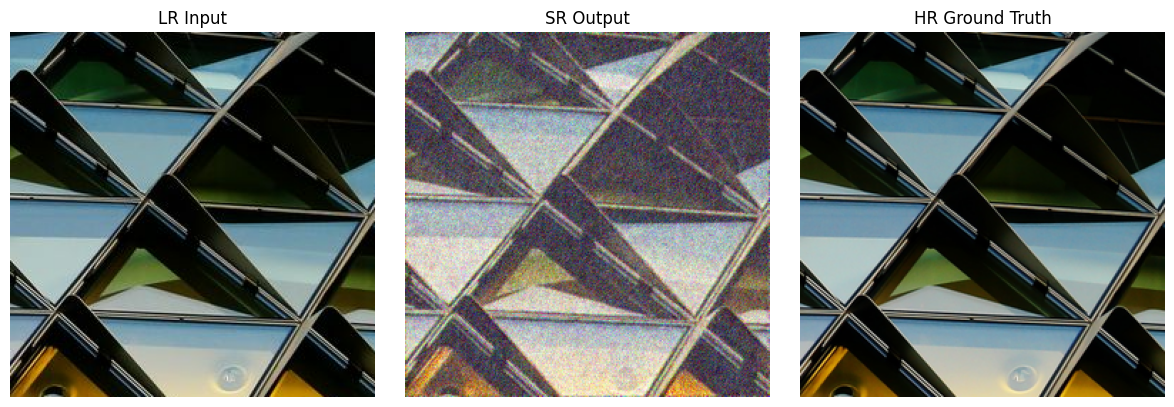

KeyboardInterrupt: 

In [24]:
print("Starting training...")

for epoch in range(epochs):
    train_bar = tqdm(train_dataset.take(steps_per_epoch), total=steps_per_epoch, desc="Training", leave=False)
    total_train_loss = 0

    for i, (lr_batch, hr_batch) in enumerate(train_bar):
        loss = train_step(hr_batch, lr_batch, model, timesteps,
                          buffers['sqrt_alphas_cumprod'], buffers['sqrt_one_minus_alphas_cumprod'])
        total_train_loss += loss
        train_bar.set_postfix(loss=float(loss))

    avg_train_loss = total_train_loss / steps_per_epoch

    total_val_loss = 0
    val_steps = 100
    val_bar = tqdm(valid_dataset.take(val_steps), total=val_steps, desc="Validation", leave=False)

    all_psnr, all_ssim = [], []

    for lr_batch, hr_batch in val_bar:
        val_loss = validation_step(hr_batch, lr_batch, model, timesteps,
                                   buffers['sqrt_alphas_cumprod'], buffers['sqrt_one_minus_alphas_cumprod'])
        total_val_loss += val_loss

        sr_batch = sr3_sampling(lr_batch, model, timesteps, sampling_steps=50)
        psnr_batch = tf.image.psnr(sr_batch, hr_batch, max_val=1.0)
        ssim_batch = tf.image.ssim(sr_batch, hr_batch, max_val=1.0)

        all_psnr.extend(psnr_batch.numpy())
        all_ssim.extend(ssim_batch.numpy())

        val_bar.set_postfix(val_loss=float(val_loss))

    avg_val_loss = total_val_loss / val_steps
    mean_psnr = np.mean(all_psnr)
    mean_ssim = np.mean(all_ssim)

    print(f"Epoch {epoch+1}/{epochs} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | PSNR: {mean_psnr:.2f} | SSIM: {mean_ssim:.4f}")

    if (epoch + 1) % 10 == 0:
        visualize_sample(model, train_dataset, timesteps, epoch=epoch, save_dir="/content/drive/MyDrive/Rezultati/")
        model.save_weights(f"/content/drive/MyDrive/Weights/model_weights_epoch_{epoch+1}.weights.h5")
        print(f"Saved model weights at epoch {epoch+1}")